# Conditional Font Generation using Variational Autoencoders

A Conditional Variational Autoencoder (CVAE) was developed using PyTorch to generate font character outlines based on style and character conditions. The model learned meaningful latent representations of font designs, enabling the creation of new and diverse character variations. This project demonstrates the application of generative AI and deep learning for typography synthesis.



In [72]:
# importing libraries
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader



In [58]:
# Define paths and load labels
DATA_ROOT = "font_outlines"
DATA_DIR = os.path.join(DATA_ROOT, "train") if os.path.isdir(os.path.join(DATA_ROOT, "train")) else DATA_ROOT
SHAPES_DIR = os.path.join(DATA_DIR, "shapes")
LABELS_PATH = os.path.join(DATA_DIR, "labels.csv")

df = pd.read_csv(LABELS_PATH)

classes = ["c", "n", "s", "v", "z"]
label_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_label = {i: c for c, i in label_to_idx.items()}

df["label_idx"] = df["label"].map(label_to_idx)

df.head()

,shape_id,label,num_points,font_family,label_idx
0,0,c,164,42dot Sans Light,0
1,1,n,178,42dot Sans Light,1
2,2,s,184,42dot Sans Light,2
3,3,v,147,42dot Sans Light,3
4,4,z,189,42dot Sans Light,4


In [59]:
# Function to resample closed curves to a fixed number of points
def resample_closed_curve(points, target_points=160):
    points = np.asarray(points, dtype=np.float32)
    closed = np.vstack([points, points[0:1]])

    segment_lengths = np.linalg.norm(np.diff(closed, axis=0), axis=1)
    cumulative = np.concatenate([[0], np.cumsum(segment_lengths)])
    total_length = cumulative[-1]

    sample_distances = np.linspace(0, total_length, target_points + 1)[:-1]
    new_points = []

    for d in sample_distances:
        idx = np.searchsorted(cumulative, d, side="right") - 1
        idx = min(idx, len(segment_lengths) - 1)

        start = closed[idx]
        end = closed[idx + 1]
        seg_len = segment_lengths[idx]

        if seg_len == 0:
            new_points.append(start)
        else:
            t = (d - cumulative[idx]) / seg_len
            new_points.append((1 - t) * start + t * end)

    return np.asarray(new_points, dtype=np.float32)


# Dataset class for font outlines
class FontOutlineDataset(Dataset):
    def __init__(self, df, shapes_dir, target_points=160, augment=False):
        self.df = df.reset_index(drop=True)
        self.shapes_dir = shapes_dir
        self.target_points = target_points
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        shape_id = int(row["shape_id"])
        label = int(row["label_idx"])

        path = os.path.join(self.shapes_dir, f"{shape_id:05d}.npy")
        points = np.load(path).astype(np.float32)
        points = resample_closed_curve(points, self.target_points)

        if self.augment:
            scale = np.random.uniform(0.94, 1.06)
            shift = np.random.uniform(-0.03, 0.03, size=(1, 2))
            noise = np.random.normal(0, 0.008, size=points.shape)

            points = points * scale + shift + noise
            points = np.clip(points, -1.0, 1.0)

        return torch.tensor(points, dtype=torch.float32), torch.tensor(label)

In [60]:
# Hyperparameters and DataLoader setup
TARGET_POINTS = 160
LATENT_DIM = 32
BATCH_SIZE = 128

dataset = FontOutlineDataset(
    df,
    SHAPES_DIR,
    target_points=TARGET_POINTS,
    augment=True
)

loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True
)

device = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

device

'mps'

In [61]:
# Define the Conditional Variational Autoencoder (CVAE) architecture
class ConditionalVAE(nn.Module):
    def __init__(self, num_points=160, num_classes=5, latent_dim=32, label_dim=16):
        super().__init__()

        self.num_points = num_points
        self.latent_dim = latent_dim

        self.label_emb = nn.Embedding(num_classes, label_dim)

        self.encoder = nn.Sequential(
            nn.Conv1d(2 + label_dim, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.2),

            nn.Conv1d(64, 128, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),

            nn.Conv1d(128, 256, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),

            nn.Conv1d(256, 256, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),
        )

        reduced_points = math.ceil(num_points / 8)
        enc_dim = 256 * reduced_points

        self.fc_mu = nn.Linear(enc_dim, latent_dim)
        self.fc_logvar = nn.Linear(enc_dim, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim + label_dim, 256),
            nn.ReLU(),

            nn.Linear(256, 512),
            nn.ReLU(),

            nn.Linear(512, 1024),
            nn.ReLU(),

            nn.Linear(1024, num_points * 2),
            nn.Tanh()
        )

    def encode(self, x, y):
        emb = self.label_emb(y)
        emb = emb.unsqueeze(1).repeat(1, self.num_points, 1)

        x = torch.cat([x, emb], dim=-1)
        x = x.permute(0, 2, 1)

        h = self.encoder(x)
        h = h.flatten(start_dim=1)

        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)

        return mu, logvar

    def reparameterise(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, y):
        emb = self.label_emb(y)
        z = torch.cat([z, emb], dim=-1)
        out = self.decoder(z)
        return out.view(-1, self.num_points, 2)

    def forward(self, x, y):
        mu, logvar = self.encode(x, y)
        z = self.reparameterise(mu, logvar)
        recon = self.decode(z, y)
        return recon, mu, logvar

model = ConditionalVAE(
    num_points=TARGET_POINTS,
    num_classes=5,
    latent_dim=LATENT_DIM
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)

def vae_loss(recon, x, mu, logvar, beta):
    recon_loss = F.mse_loss(recon, x)
    kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + beta * kl_loss, recon_loss, kl_loss

## Preprocessing, Training, and Hyperparameter Tuning

Font outlines were resampled to 160 points and augmented using scaling, translation, and Gaussian noise to improve model generalisation. Beta annealing (0 to 0.1) was applied during training to prevent posterior collapse and encourage meaningful latent representations while maintaining reconstruction quality.


In [62]:
# Training loop
EPOCHS = 200

history = []

for epoch in range(1, EPOCHS + 1):
    model.train()

    total_loss = 0
    total_recon = 0
    total_kl = 0

    beta = min(0.1, 0.1* epoch / 50)


    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        recon, mu, logvar = model(x, y)
        loss, recon_loss, kl_loss = vae_loss(recon, x, mu, logvar, beta)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_recon += recon_loss.item()
        total_kl += kl_loss.item()

    n = len(loader)
    history.append([total_loss / n, total_recon / n, total_kl / n])

    if epoch % 20 == 1: 
        print(
            f"Epoch {epoch:03d} | "
            f"loss={total_loss/n:.5f} | "
            f"recon={total_recon/n:.5f} | "
            f"kl={total_kl/n:.5f} | "
            f"beta={beta:.5f}"
        )


Epoch 001 | loss=0.09764 | recon=0.09160 | kl=3.02183 | beta=0.00200
Epoch 021 | loss=0.02685 | recon=0.01380 | kl=0.31064 | beta=0.04200
Epoch 041 | loss=0.03366 | recon=0.01560 | kl=0.22029 | beta=0.08200
Epoch 061 | loss=0.03467 | recon=0.01570 | kl=0.18977 | beta=0.10000
Epoch 081 | loss=0.03319 | recon=0.01492 | kl=0.18272 | beta=0.10000
Epoch 101 | loss=0.03271 | recon=0.01448 | kl=0.18228 | beta=0.10000
Epoch 121 | loss=0.03206 | recon=0.01391 | kl=0.18146 | beta=0.10000
Epoch 141 | loss=0.03110 | recon=0.01321 | kl=0.17884 | beta=0.10000
Epoch 161 | loss=0.03129 | recon=0.01340 | kl=0.17890 | beta=0.10000
Epoch 181 | loss=0.03101 | recon=0.01294 | kl=0.18073 | beta=0.10000


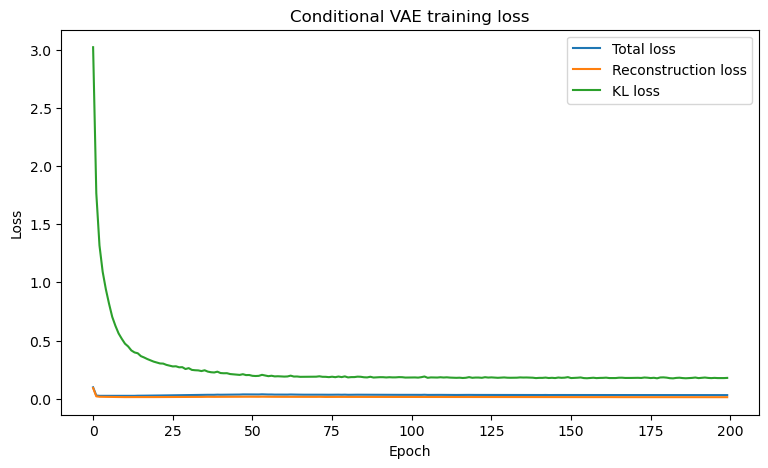

In [63]:
# Plot training history
plt.figure(figsize=(9, 5))
history = np.array(history)

plt.plot(history[:, 0], label="Total loss")
plt.plot(history[:, 1], label="Reconstruction loss")
plt.plot(history[:, 2], label="KL loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Conditional VAE training loss")
plt.show()



In [64]:
def plot_outline(ax, points, title=None):
    points = np.asarray(points)
    closed = np.vstack([points, points[0:1]])

    ax.plot(closed[:, 0], closed[:, 1], color="royalblue", linewidth=1.5)
    ax.scatter(points[:, 0], points[:, 1], color="red", s=4)

    ax.set_xlim(-1.15, 1.15)
    ax.set_ylim(-1.15, 1.15)
    ax.set_aspect("equal")
    ax.axis("off")

    if title is not None:
        ax.set_title(title, fontsize=10)

train_loader -> torch.Size([128, 3, 128, 128]) torch.Size([128])
val_loader -> torch.Size([128, 3, 128, 128]) torch.Size([128])
loader -> torch.Size([128, 160, 2]) torch.Size([128])
Using outline loader: loader


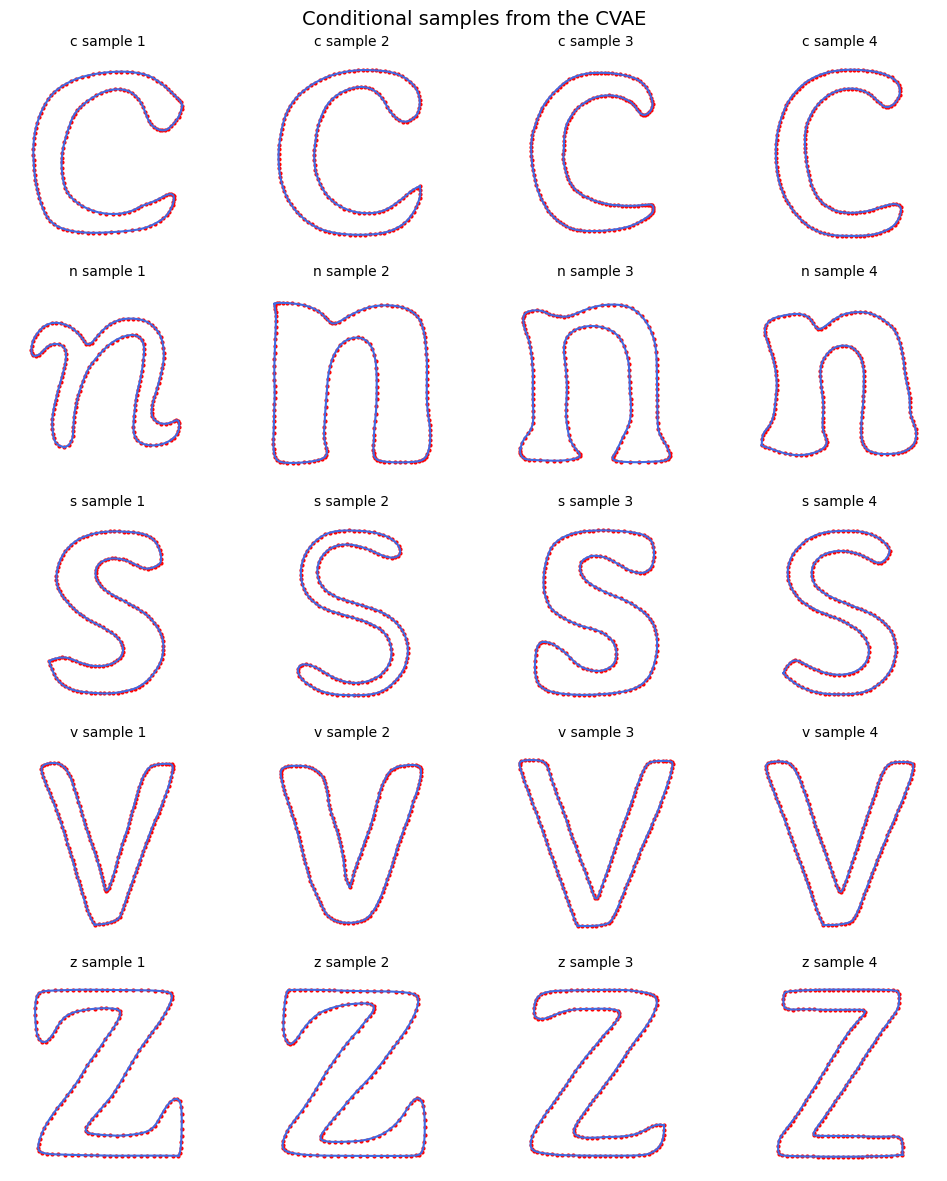

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt

def find_outline_loader():
    for name, obj in globals().items():
        if "loader" not in name.lower():
            continue

        try:
            batch = next(iter(obj))
            x = batch[0]
            y = batch[1]

            print(name, "->", x.shape, y.shape)

            if (
                (x.ndim == 3 and x.shape[-1] == 2) or
                (x.ndim == 3 and x.shape[1] == 2) or
                (x.ndim == 4 and x.shape[-1] == 2)
            ):
                print("Using outline loader:", name)
                return obj

        except Exception:
            pass

    raise ValueError(
        "No outline dataloader found. "
        "[B, 3, 128, 128]. CVAE needs outline coordinates [B, N, 2]."
    )


outline_loader = find_outline_loader()



def fix_outline_shape(x):
    x = x.float()

    # (B, 1, N, 2) -> (B, N, 2)
    if x.ndim == 4 and x.shape[1] == 1 and x.shape[-1] == 2:
        x = x.squeeze(1)

    # (B, N, 2, 1) -> (B, N, 2)
    if x.ndim == 4 and x.shape[-1] == 1 and x.shape[-2] == 2:
        x = x.squeeze(-1)

    # (B, 2, N) -> (B, N, 2)
    if x.ndim == 3 and x.shape[1] == 2:
        x = x.permute(0, 2, 1)

    if x.ndim != 3 or x.shape[-1] != 2:
        raise ValueError(f"Wrong outline shape: {x.shape}. Need (B, N, 2).")

    return x



def smooth_outline(points, alpha=0.20, passes=2):
    pts = np.asarray(points).copy()

    for _ in range(passes):
        pts[1:-1] = (
            (1 - alpha) * pts[1:-1]
            + alpha * 0.5 * (pts[:-2] + pts[2:])
        )

    return pts


def is_valid_outline(points, min_area=0.03, max_jump_ratio=6.0):
    pts = np.asarray(points)

    w = pts[:, 0].max() - pts[:, 0].min()
    h = pts[:, 1].max() - pts[:, 1].min()

    if w * h < min_area:
        return False

    diffs = np.linalg.norm(np.diff(pts, axis=0), axis=1)

    if diffs.mean() == 0:
        return False

    if diffs.max() > max_jump_ratio * diffs.mean():
        return False

    return True



def build_class_latent_bank(model, dataloader, max_per_class=80):
    model.eval()
    bank = {c: [] for c in classes}

    with torch.no_grad():
        for batch in dataloader:
            x = batch[0].to(device)
            y = batch[1].to(device).long()

            x = fix_outline_shape(x)

            mu, logvar = model.encode(x, y)

            for i in range(x.size(0)):
                char = classes[y[i].item()]

                if len(bank[char]) < max_per_class:
                    bank[char].append(mu[i].detach().cpu())

            if all(len(bank[c]) >= max_per_class for c in classes):
                break

    for c in classes:
        if len(bank[c]) == 0:
            raise ValueError(f"No examples found for class '{c}' in outline_loader")

        bank[c] = torch.stack(bank[c]).to(device)

    return bank


latent_bank = build_class_latent_bank(
    model,
    outline_loader,
    max_per_class=80
)



def generate_clean_samples(model, char, n_samples=4, noise_std=0.03, max_tries=300):
    model.eval()

    label_idx = label_to_idx[char]
    y = torch.tensor([label_idx], dtype=torch.long, device=device)

    valid = []

    with torch.no_grad():
        attempts = 0

        while len(valid) < n_samples and attempts < max_tries:
            bank = latent_bank[char]

            idx = torch.randint(0, len(bank), (1,), device=device)
            base_z = bank[idx]

            z = base_z + noise_std * torch.randn_like(base_z)

            sample = model.decode(z, y).cpu().numpy()[0]
            sample = smooth_outline(sample, alpha=0.20, passes=2)

            if is_valid_outline(sample):
                valid.append(sample)

            attempts += 1

        while len(valid) < n_samples:
            bank = latent_bank[char]

            idx = torch.randint(0, len(bank), (1,), device=device)
            base_z = bank[idx]

            sample = model.decode(base_z, y).cpu().numpy()[0]
            sample = smooth_outline(sample, alpha=0.20, passes=2)

            valid.append(sample)

    return valid[:n_samples]


fig, axes = plt.subplots(5, 4, figsize=(10, 12))

for row, char in enumerate(classes):
    samples = generate_clean_samples(
        model,
        char,
        n_samples=4,
        noise_std=0.03
    )

    for col in range(4):
        plot_outline(
            axes[row, col],
            samples[col],
            title=f"{char} sample {col + 1}"
        )

plt.suptitle("Conditional samples from the CVAE", fontsize=14)
plt.tight_layout()
plt.show()

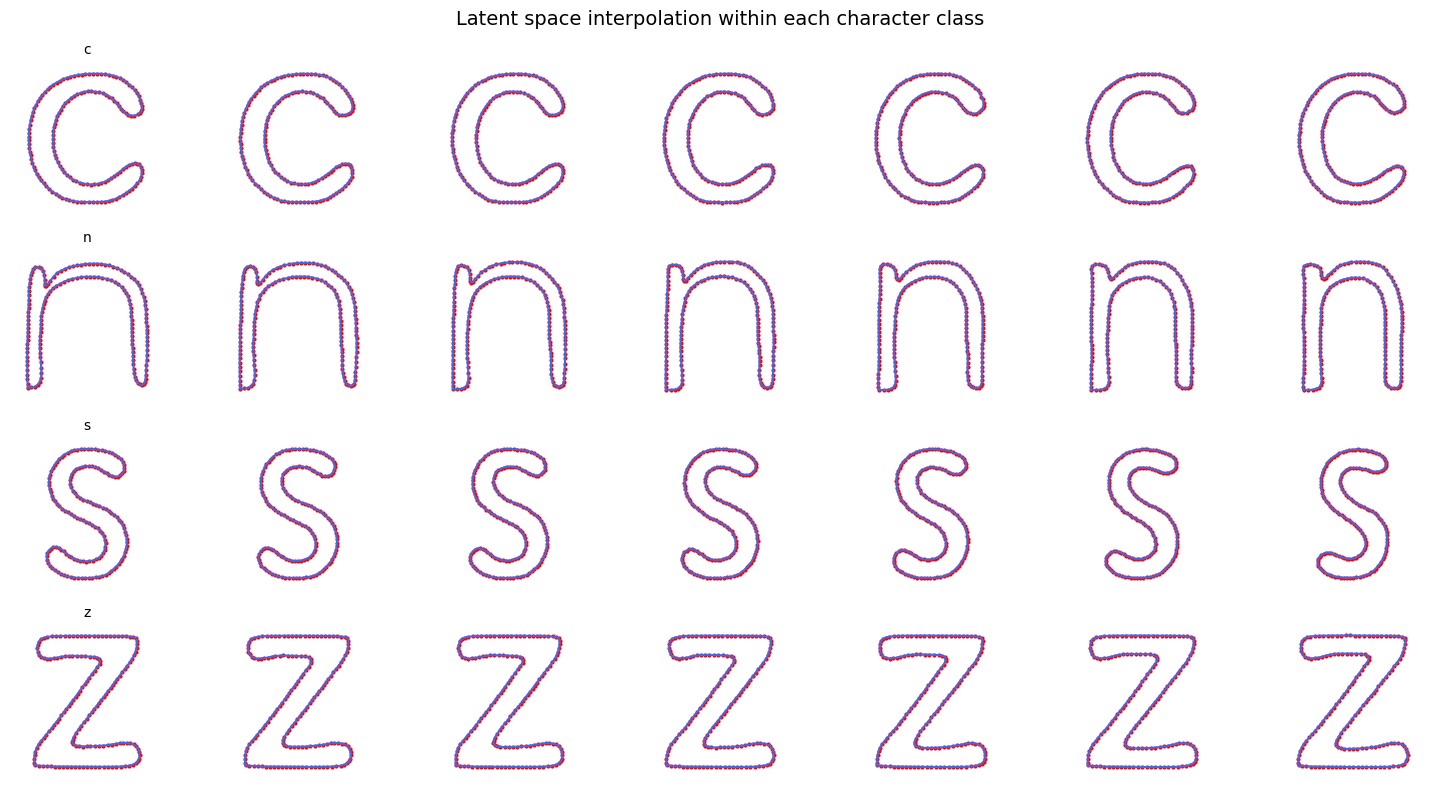

In [77]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def latent_interpolation_clean(model, char, steps=7, max_pair_dist=1.5):
    model.eval()
    label_idx = label_to_idx[char]

    bank = latent_bank[char]

    with torch.no_grad():
        
        i = torch.randint(0, len(bank), (1,), device=device).item()
        z1 = bank[i]

       
        dists = torch.norm(bank - z1, dim=1)

        valid = torch.where((dists > 0.05) & (dists < max_pair_dist))[0]

        if len(valid) == 0:
            
            valid = torch.argsort(dists)[1:10]

        j = valid[torch.randint(0, len(valid), (1,), device=device)].item()
        z2 = bank[j]

        alphas = torch.linspace(0, 1, steps, device=device)

        z_interp = torch.stack([
            (1 - a) * z1 + a * z2
            for a in alphas
        ])

        y_interp = torch.full(
            (steps,),
            label_idx,
            dtype=torch.long,
            device=device
        )

        outlines = model.decode(z_interp, y_interp).cpu().numpy()

    return outlines


interp_classes = ["c", "n", "s", "z"]

fig, axes = plt.subplots(len(interp_classes), 7, figsize=(15, 8))

for row, char in enumerate(interp_classes):
    outlines = latent_interpolation_clean(
        model,
        char,
        steps=7,
        max_pair_dist=1.0
    )

    for col in range(7):
        title = char if col == 0 else None
        plot_outline(
            axes[row, col],
            outlines[col],
            title=title
        )

plt.suptitle("Latent space interpolation within each character class", fontsize=14)
plt.tight_layout()
plt.show()